In [1]:
from itertools import cycle, islice

import matplotlib.pyplot as plt
import numpy as np
from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler

Let's generate a set of synthetic dataset for demostration


In [2]:
n_samples = 1500
noisy_circles = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=42
)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=42)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=42)
rng = np.random.RandomState(42)
no_structure = rng.rand(n_samples, 2), None

# Anisotropicly distributed data
X, y = datasets.make_blobs(n_samples=n_samples, random_state=42)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=42
)

In [3]:
datasets = [
    (noisy_circles, {"n_clusters": 2}),
    (noisy_moons, {"n_clusters": 2}),
    (varied, {"n_clusters": 3}),
    (aniso, {"n_clusters": 3}),
    (blobs, {"n_clusters": 3}),
    (no_structure, {"n_clusters": 3}),
]

Let's do the clustering and plot them


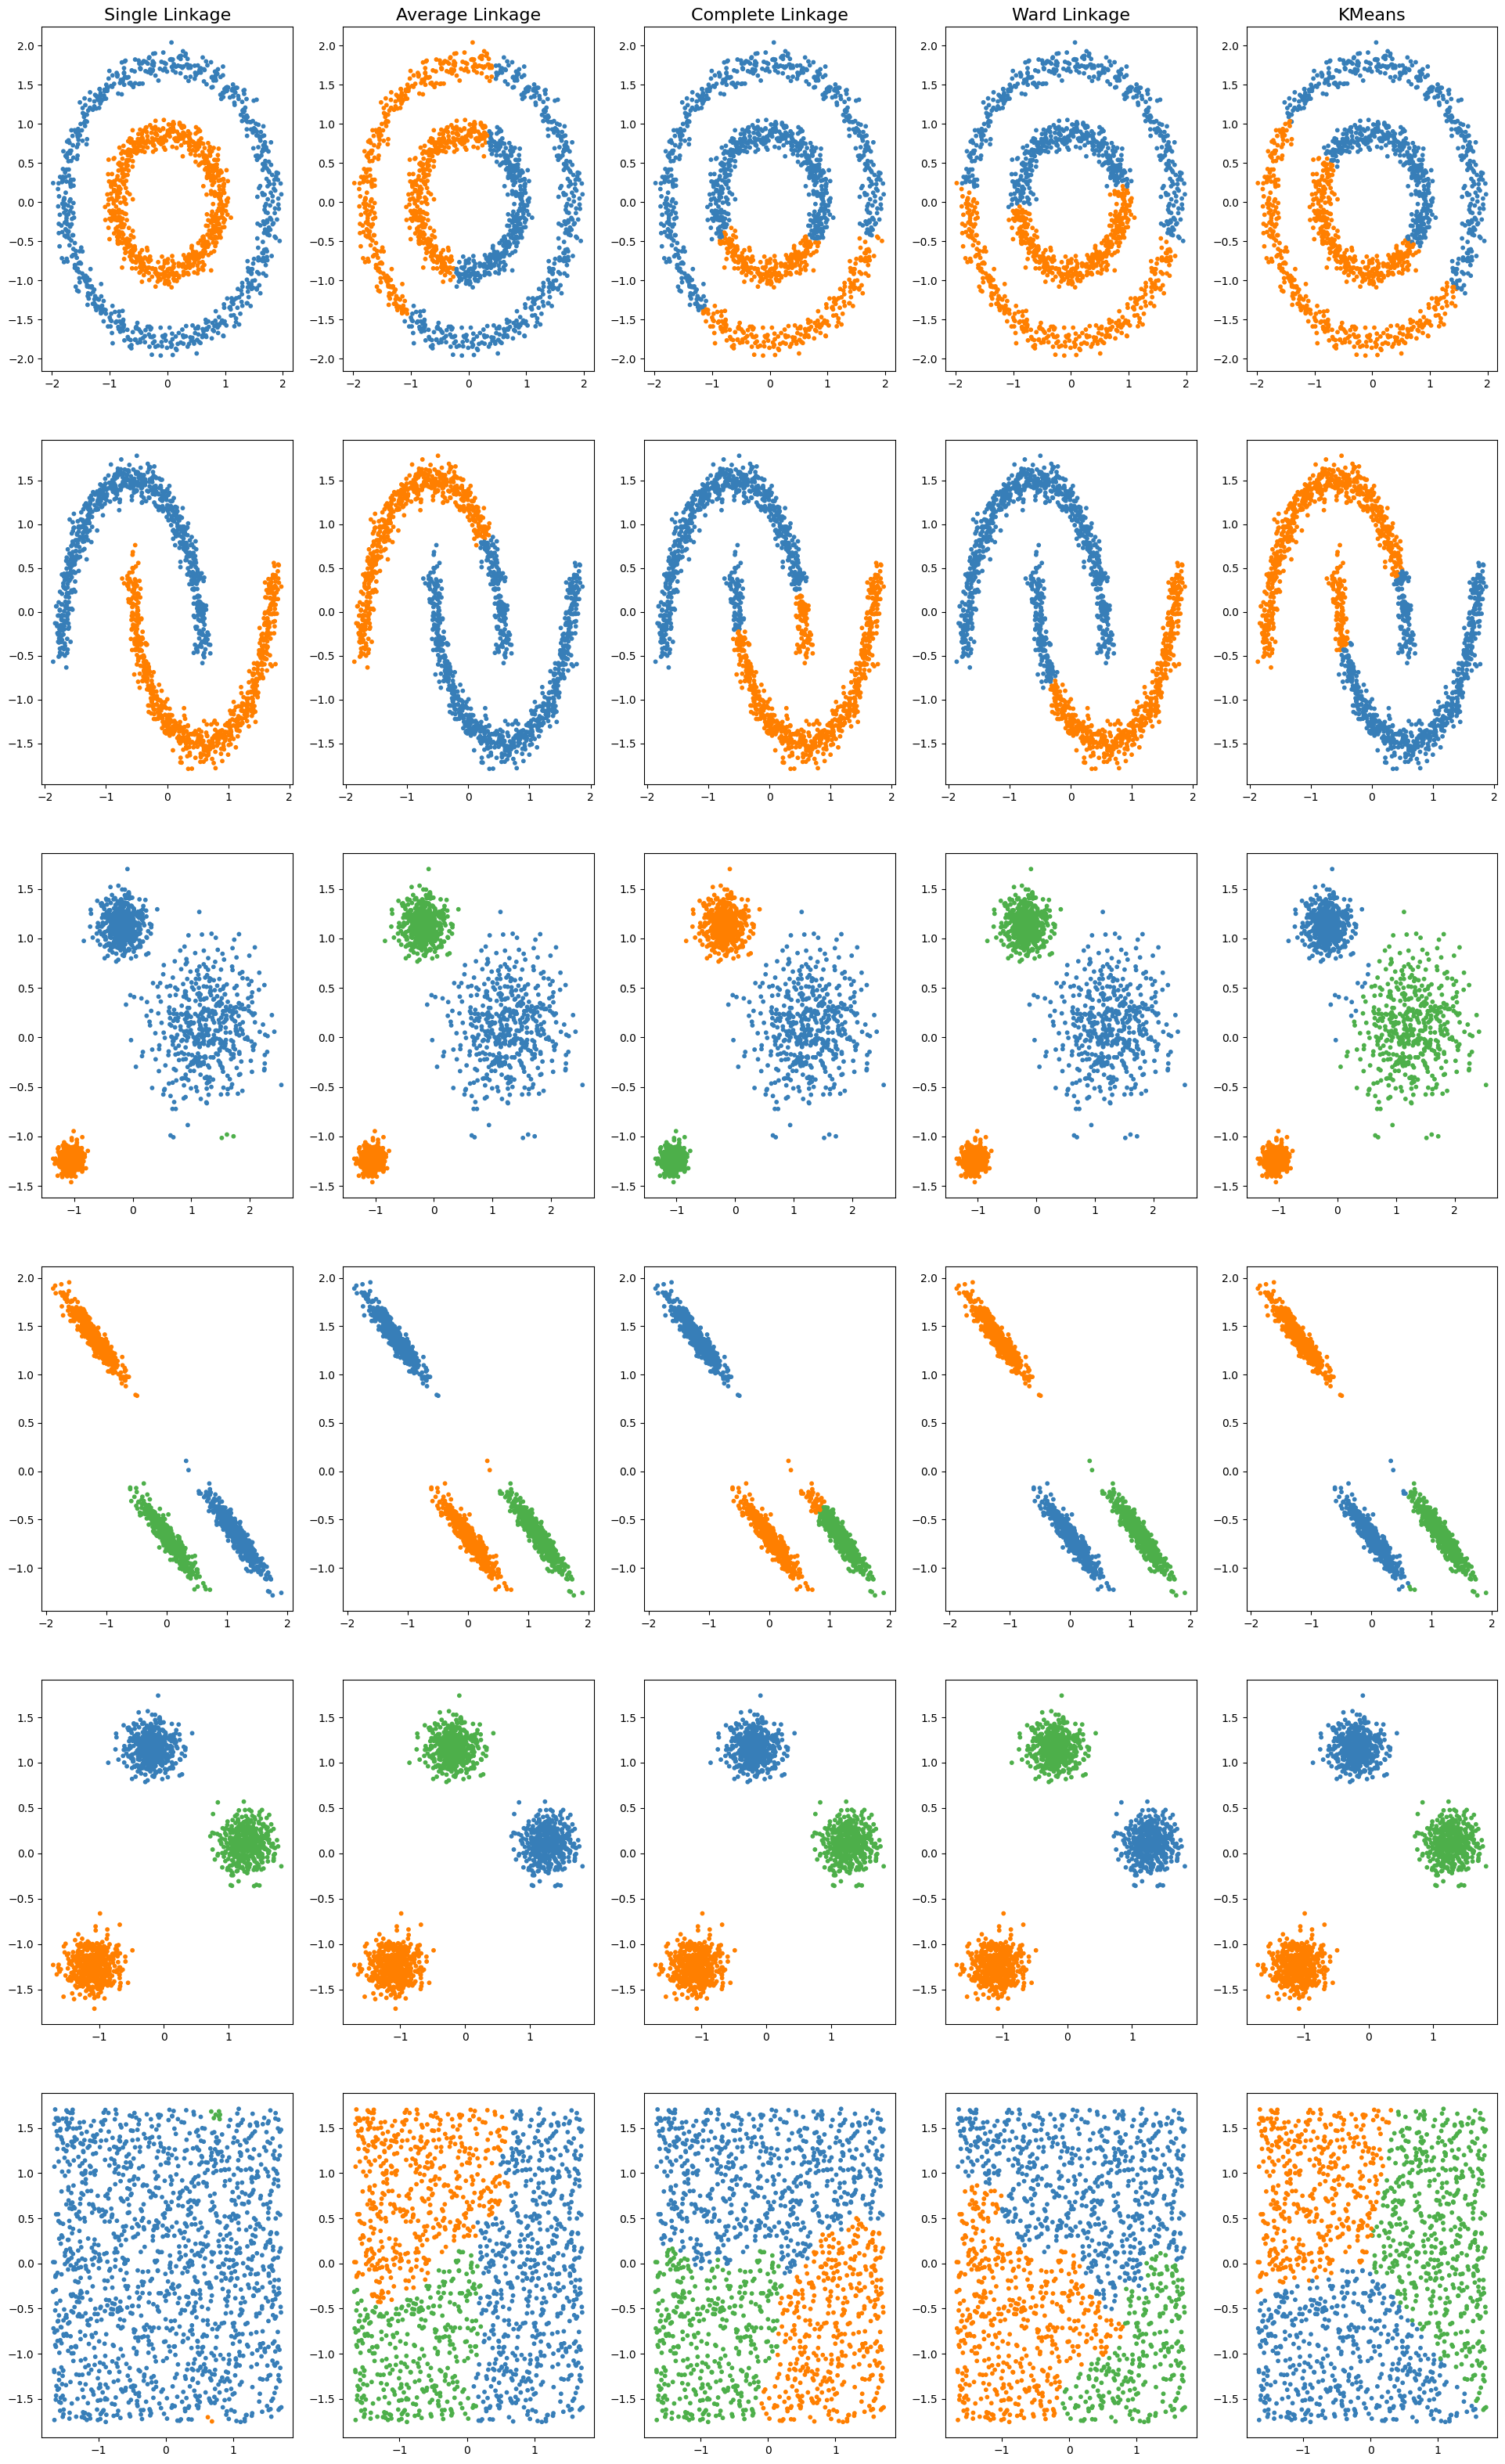

In [4]:
fig, axs = plt.subplots(len(datasets), 5, figsize=(24, 40))

for i, (datasets, algo_params) in enumerate(datasets):
    # import dataset and normalize it
    X, y = datasets
    X = StandardScaler().fit_transform(X)

    # Create cluster objects
    ward = cluster.AgglomerativeClustering(
        n_clusters=algo_params["n_clusters"], linkage="ward"
    )
    complete = cluster.AgglomerativeClustering(
        n_clusters=algo_params["n_clusters"], linkage="complete"
    )
    average = cluster.AgglomerativeClustering(
        n_clusters=algo_params["n_clusters"], linkage="average"
    )
    single = cluster.AgglomerativeClustering(
        n_clusters=algo_params["n_clusters"], linkage="single"
    )
    kmeans = cluster.KMeans(n_clusters=algo_params["n_clusters"])

    clustering_algorithms = (
        ("Single Linkage", single),
        ("Average Linkage", average),
        ("Complete Linkage", complete),
        ("Ward Linkage", ward),
        ("KMeans", kmeans),
    )

    for j, (name, algorithm) in enumerate(clustering_algorithms):
        algorithm.fit(X)

        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        if i == 0:
            axs[i, j].set_title(name, size=16)

        colors = np.array(
            list(
                islice(
                    cycle(
                        [
                            "#377eb8",
                            "#ff7f00",
                            "#4daf4a",
                            "#f781bf",
                            "#a65628",
                            "#984ea3",
                            "#999999",
                            "#e41a1c",
                            "#dede00",
                        ]
                    ),
                    int(max(y_pred) + 1),
                )
            )
        )
        axs[i, j].scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

plt.show()